In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("diabetes_prediction_dataset .csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0.0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0.0
2,Male,28.0,0,0,never,27.32,5.7,158,0.0
3,Female,36.0,0,0,current,23.45,5.0,155,0.0
4,Male,76.0,1,1,current,20.14,4.8,155,0.0


In [5]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
82560,Female,7.0,0,0,never,19.74,6.2,200,0.0
82561,Female,2.0,0,0,No Info,16.45,6.0,80,0.0
82562,Male,49.0,0,0,current,31.44,3.5,158,0.0
82563,Female,50.0,0,0,current,27.32,6.2,200,0.0
82564,Female,49.0,0,0,No Info,37.60,4.0,155,NaN


In [7]:
df_zero = df[df['diabetes'] == 0]
rows_to_drop = df_zero.sample(n=64049, random_state=42).index
df_new = df.drop(rows_to_drop)
print("Before:", df.shape)
print("After:", df_new.shape)
df_new.to_csv('cleaned_dataset.csv', index=False)

Before: (82565, 9)
After: (18516, 9)


In [8]:
df_new = df.drop(rows_to_drop)

In [9]:
df = df_new.copy()

In [10]:
df_new.to_csv('cleaned_dataset.csv', index=False)

In [11]:
df = pd.read_csv('cleaned_dataset.csv')

print(df.shape)

(18516, 9)


In [12]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
18511,Female,65.0,0,0,former,31.00,6.2,90,0.0
18512,Female,16.0,0,0,No Info,22.93,4.8,130,0.0
18513,Female,79.0,0,0,No Info,25.19,4.5,85,0.0
18514,Female,62.0,0,0,never,33.42,9.0,240,1.0
18515,Female,49.0,0,0,No Info,37.60,4.0,155,NaN


In [13]:
df.shape

(18516, 9)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18516 entries, 0 to 18515
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               18516 non-null  object 
 1   age                  18516 non-null  float64
 2   hypertension         18516 non-null  int64  
 3   heart_disease        18516 non-null  int64  
 4   smoking_history      18516 non-null  object 
 5   bmi                  18516 non-null  float64
 6   HbA1c_level          18516 non-null  float64
 7   blood_glucose_level  18516 non-null  int64  
 8   diabetes             18515 non-null  float64
dtypes: float64(4), int64(3), object(2)
memory usage: 1.3+ MB


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,18516.0,47.978531,22.119237,0.08,32.00,51.00,66.00,80.00
hypertension,18516.0,0.131022,0.337433,0.00,0.00,0.00,0.00,1.00
heart_disease,18516.0,0.074206,0.262113,0.00,0.00,0.00,0.00,1.00
bmi,18516.0,28.828666,7.288122,10.60,25.18,27.32,31.91,88.72
HbA1c_level,18516.0,5.975637,1.262582,3.50,5.00,6.00,6.60,9.00
blood_glucose_level,18516.0,155.900897,54.040724,80.00,126.00,145.00,160.00,300.00
diabetes,18515.0,0.378882,0.485122,0.00,0.00,0.00,1.00,1.00


In [16]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,1


In [17]:
df.duplicated().sum()

np.int64(75)

In [18]:
df["diabetes"].value_counts()

,count
diabetes,
0.0,11500
1.0,7015


In [19]:
df["diabetes"].value_counts(normalize=True) * 100

,proportion
diabetes,
0.0,62.111801
1.0,37.888199


In [20]:
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
age,18516.0,47.978531,22.119237,0.08,32.00,51.00,66.00,80.00
hypertension,18516.0,0.131022,0.337433,0.00,0.00,0.00,0.00,1.00
heart_disease,18516.0,0.074206,0.262113,0.00,0.00,0.00,0.00,1.00
bmi,18516.0,28.828666,7.288122,10.60,25.18,27.32,31.91,88.72
HbA1c_level,18516.0,5.975637,1.262582,3.50,5.00,6.00,6.60,9.00
blood_glucose_level,18516.0,155.900897,54.040724,80.00,126.00,145.00,160.00,300.00
diabetes,18515.0,0.378882,0.485122,0.00,0.00,0.00,1.00,1.00


In [21]:
categorical_cols = ["gender", "smoking_history"]

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for gender:
gender
Female    10517
Male       7998
Other         1
Name: count, dtype: int64

Value counts for smoking_history:
smoking_history
never          6793
No Info        5548
former         2266
current        1821
not current    1253
ever            835
Name: count, dtype: int64


In [22]:
print("Unique values in each column:")
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique values in each column:
gender : 3
age : 102
hypertension : 2
heart_disease : 2
smoking_history : 6
bmi : 3343
HbA1c_level : 18
blood_glucose_level : 18
diabetes : 2


In [23]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:")
print(numerical_cols)

Numerical columns:
Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes'],
      dtype='object')


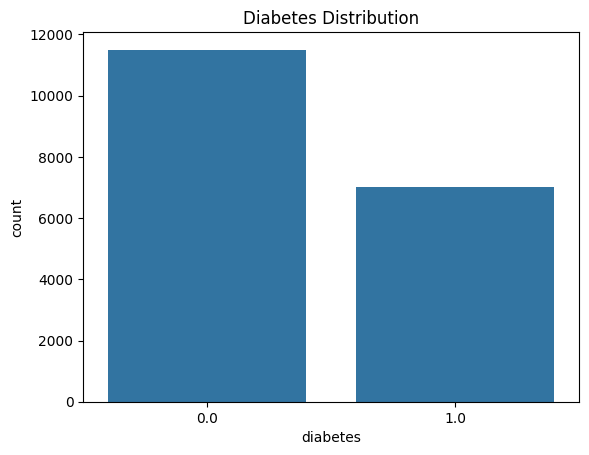

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="diabetes", data=df)
plt.title("Diabetes Distribution")
plt.show()

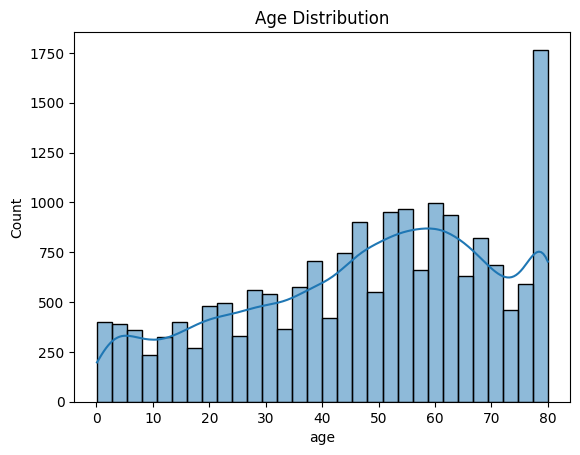

In [25]:
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

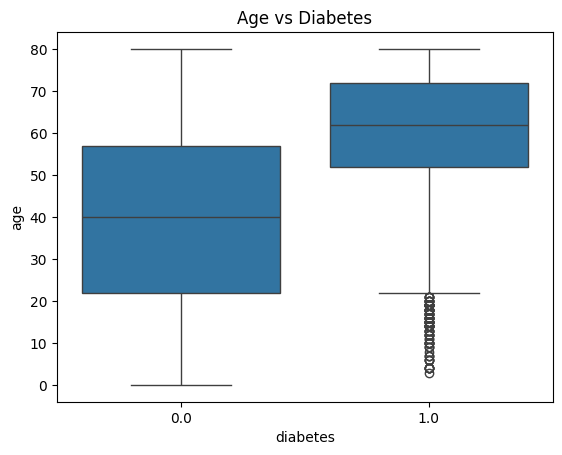

In [26]:
sns.boxplot(x="diabetes", y="age", data=df)
plt.title("Age vs Diabetes")
plt.show()

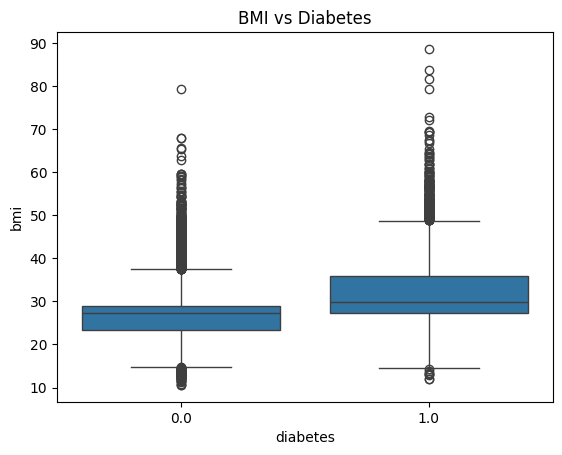

In [27]:
sns.boxplot(x="diabetes", y="bmi", data=df)
plt.title("BMI vs Diabetes")
plt.show()

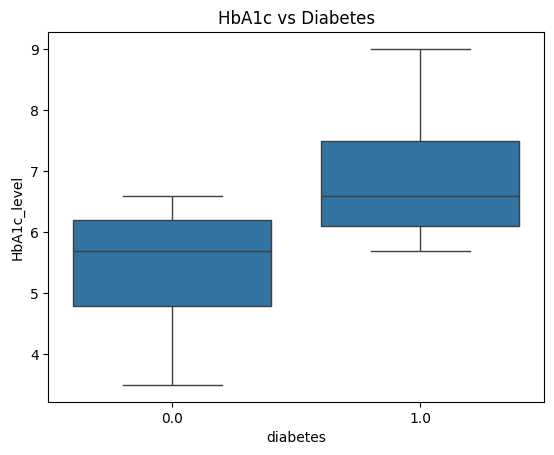

In [28]:
sns.boxplot(x="diabetes", y="HbA1c_level", data=df)
plt.title("HbA1c vs Diabetes")
plt.show()

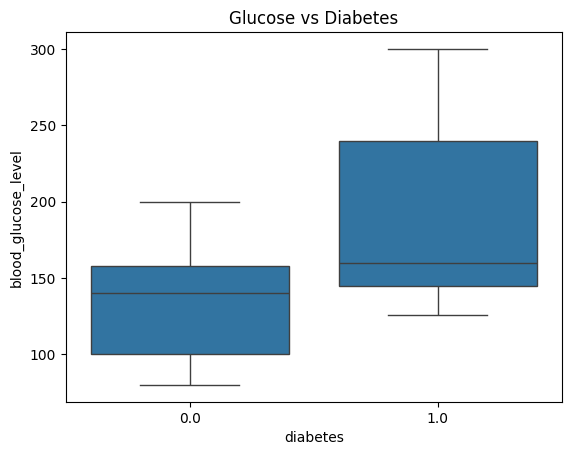

In [29]:
sns.boxplot(x="diabetes", y="blood_glucose_level", data=df)
plt.title("Glucose vs Diabetes")
plt.show()

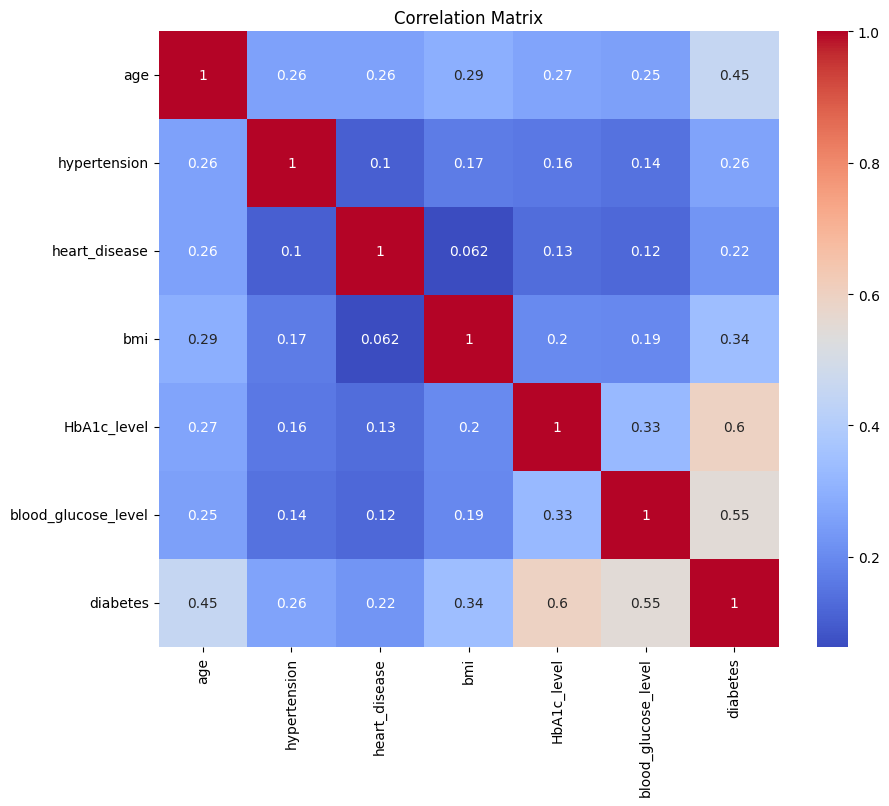

In [30]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

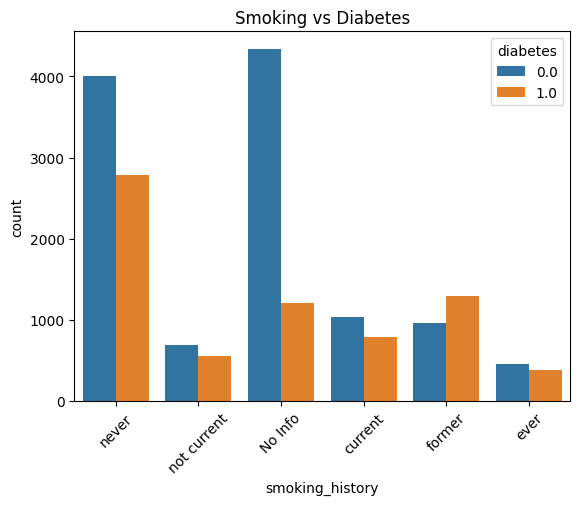

In [31]:
sns.countplot(x="smoking_history", hue="diabetes", data=df)
plt.xticks(rotation=45)
plt.title("Smoking vs Diabetes")
plt.show()

In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["smoking_history"] = le.fit_transform(df["smoking_history"])

In [33]:
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

In [36]:
from sklearn.model_selection import train_test_split

# Drop rows where 'diabetes' is NaN before splitting
df_cleaned = df.dropna(subset=['diabetes'])
X = df_cleaned.drop("diabetes", axis=1)
y = df_cleaned["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [51]:
y_prob = xgb_model.predict_proba(X_test)[:,1]

# جرّب كذا threshold
threshold = 0.3
y_pred = (y_prob > threshold).astype(int)

In [60]:
xgb = XGBClassifier(scale_pos_weight=2)

In [62]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss'
    )
}

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

results = []

for name, model in models.items():


    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, prec, rec, auc])

In [64]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "ROC-AUC"]
)

print(results_df.sort_values(by="ROC-AUC", ascending=False))

                 Model  Accuracy  Precision    Recall   ROC-AUC
2              XGBoost  0.917094   0.900000  0.878831  0.981186
1        Random Forest  0.909263   0.890271  0.867427  0.976679
0  Logistic Regression  0.886849   0.835150  0.873842  0.963144


In [65]:
xgb_model = models["XGBoost"]

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

               Feature  Importance
6          HbA1c_level    0.463186
7  blood_glucose_level    0.267332
1                  age    0.078532
3        heart_disease    0.061925
2         hypertension    0.061030
5                  bmi    0.030389
4      smoking_history    0.023687
0               gender    0.013919


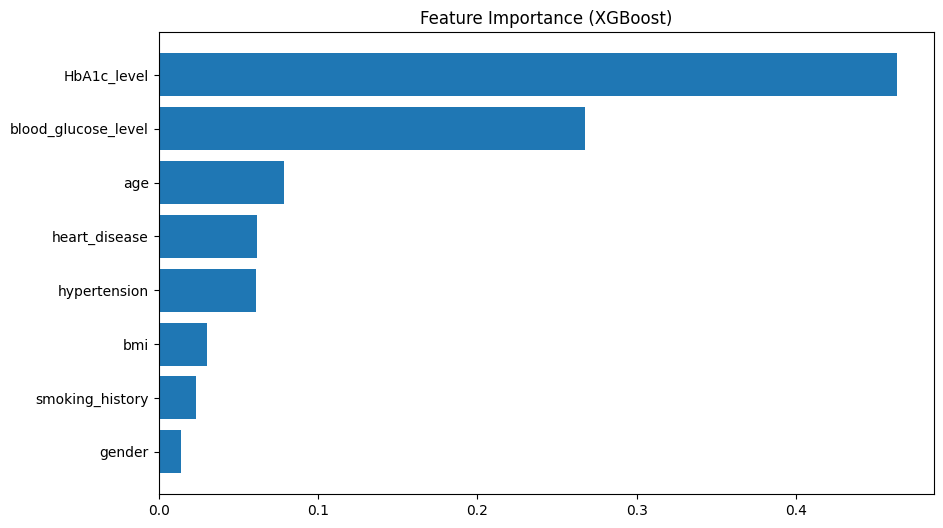

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (XGBoost)")
plt.show()

In [67]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd

# Reuse the 'models' dictionary that already contains the trained models
# The 'models' dictionary was defined in EDshTR42Vtcz and trained in jRM8OS9cWXXN

results = []

for name, m in models.items():
    if name == "Logistic Regression":
        y_pred = m.predict(X_test_scaled)
        y_prob = m.predict_proba(X_test_scaled)[:,1]
    else:
        y_pred = m.predict(X_test)
        y_prob = m.predict_proba(X_test)[:,1] # Get probabilities for ROC AUC

    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob) # Use y_prob for ROC AUC

    print(f"\n📌 Model: {name}")
    print("Accuracy:", acc)
    print("ROC AUC:", roc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    results.append([name, acc, roc])

# جدول مقارنة
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "ROC AUC"])
print("\n📊 Comparison Table:")
print(results_df)


📌 Model: Logistic Regression
Accuracy: 0.8868485012152308
ROC AUC: 0.963144194118194
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.89      0.91      2300
         1.0       0.84      0.87      0.85      1403

    accuracy                           0.89      3703
   macro avg       0.88      0.88      0.88      3703
weighted avg       0.89      0.89      0.89      3703

Confusion Matrix:
 [[2058  242]
 [ 177 1226]]

📌 Model: Random Forest
Accuracy: 0.9092627599243857
ROC AUC: 0.9766791657628064
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.93      0.93      2300
         1.0       0.89      0.87      0.88      1403

    accuracy                           0.91      3703
   macro avg       0.91      0.90      0.90      3703
weighted avg       0.91      0.91      0.91      3703

Confusion Matrix:
 [[2150  150]
 [ 186 1217]]

📌 Model: XGBoost
Accuracy: 0.917094247

In [68]:
from sklearn.model_selection import cross_val_score

for name, m in models.items():
    scores = cross_val_score(m, X, y, cv=5, scoring='roc_auc')
    print(f"\n{name} CV ROC AUC:", scores.mean())


Logistic Regression CV ROC AUC: 0.9620992593510801

Random Forest CV ROC AUC: 0.974367628373981

XGBoost CV ROC AUC: 0.979539527100313


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


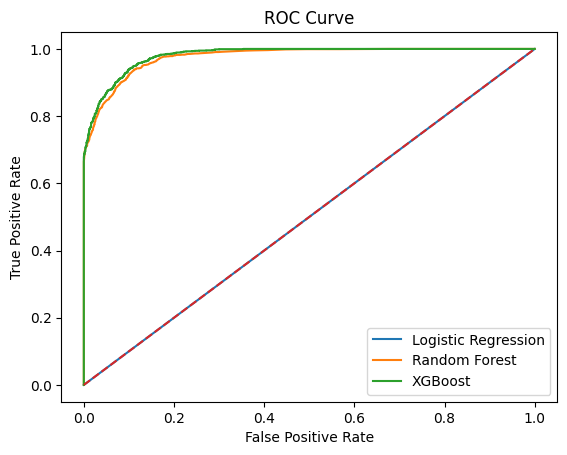

In [69]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

for name, m in models.items():
    y_prob = m.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [70]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3,5,7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1]
}

search = RandomizedSearchCV(
    XGBClassifier(),
    params,
    scoring='recall',
    cv=3,
    n_iter=10
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

In [71]:
print("Best Parameters:")
print(search.best_params_)

Best Parameters:
{'subsample': 1, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}


In [72]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9187145557655955
ROC AUC: 0.9808943568130405

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.94      0.94      2300
         1.0       0.90      0.88      0.89      1403

    accuracy                           0.92      3703
   macro avg       0.92      0.91      0.91      3703
weighted avg       0.92      0.92      0.92      3703


Confusion Matrix:
 [[2167  133]
 [ 168 1235]]


In [73]:
cm = confusion_matrix(y_test, y_pred)
fn = cm[1][0]
print("False Negatives:", fn)

False Negatives: 168


In [74]:
print("Old FN: 170")
print("New FN:", fn)

Old FN: 170
New FN: 168


In [75]:
y_prob = best_model.predict_proba(X_test)[:,1]

y_pred = (y_prob > 0.3).astype(int)

In [76]:
from sklearn.metrics import confusion_matrix, recall_score

cm = confusion_matrix(y_test, y_pred)
fn = cm[1][0]
recall = recall_score(y_test, y_pred)

print("Recall:", recall)
print("False Negatives:", fn)

Recall: 0.9529579472558802
False Negatives: 66


In [78]:
 fp = cm[0][1]
print("False Positives:", fp)

False Positives: 271


In [79]:
import joblib

joblib.dump(best_model, "diabetes_model.pkl")

['diabetes_model.pkl']

In [80]:
model = joblib.load("diabetes_model.pkl")

In [81]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [82]:
joblib.dump(le, "encoder.pkl")

['encoder.pkl']

In [83]:
joblib.dump({
    "model": best_model,
    "scaler": scaler
}, "full_pipeline.pkl")

['full_pipeline.pkl']

In [84]:
data = joblib.load("full_pipeline.pkl")

model = data["model"]
scaler = data["scaler"]